# 02 — Cleaning & EDA

## Summary
- Data funnel: 122,565 all-Portugal listings → 13,469 Lisbon → 13,028 with area → **11,764 clean** (T0–T5, 20–600 m², €50k–3M)
- Typical Lisbon apartment (2022 asking data): **~95 m², T2, ~€580k**
- Price per m² by district: from €3.7k (Lumiar, Santa Clara) to €8.8k (Alcântara) — **2.3× spread**, district is a key price driver
- Small-sample caution: Santa Clara has only 52 listings
- Data is from 2022; market has grown ~40–50% since (INE) — see README limitations

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/portugal_houses.csv")
print("Total rows:", len(df))


Total rows: 122565


In [19]:
df['category'].value_counts()

category
casas    122565
Name: count, dtype: int64

In [20]:
df['location'].value_counts().head(20)


location
Lisboa               13469
Porto                 9353
Vila Nova de Gaia     4296
Cascais               4062
Sintra                3090
Funchal               2932
Loulé                 2818
Portimão              2478
Aveiro                2144
Lagos                 2112
Braga                 2047
Seixal                1996
Albufeira             1980
Matosinhos            1967
Amadora               1880
Olhão                 1830
Oeiras                1778
Faro                  1513
Sesimbra              1497
Montijo               1495
Name: count, dtype: int64

In [21]:
df = df[(df['category'] == 'casas') & (df['location'] == 'Lisboa')]
print("After Lisbon filter:", len(df))

After Lisbon filter: 13469


In [22]:
# diagnostic: what junk values live in the area columns?
junk = df['area.net'].astype(str).str.extract(r'(\d)').isna() & df['area.net'].notna()
df.loc[junk[0], ['title', 'area.net', 'area.gross']].head(10)

,title,area.net,area.gross
95,Apartamento T3 em Avenidas Novas,NaN,NaN
148,Apartamento T1 em Campo de Ourique,NaN,41.00 m2
167,Apartamento T2 em Santa Maria Maior,NaN,119.00 m²
172,Apartamento T2 em Lumiar,NaN,90.30 m²
173,Apartamento T1 em Alcântara,NaN,93.51 m²
178,Apartamento T2 em Santo António,NaN,96.30 m²
187,Apartamento T1 em Campo de Ourique,NaN,41.00 m²
195,Apartamento T1 em Estrela,NaN,71.00 m²
198,Apartamento T1 em Misericórdia,NaN,148.20 m²
205,Apartamento T3 em Santa Clara,NaN,143.29 m²


In [23]:
def clean_area(col):
    """Turn strings like '63.00 m²' into 63.0; any junk becomes NaN."""
    # extract the first number (e.g. 63 or 63.00) from the string
    numbers = col.astype(str).str.extract(r'(\d+(?:\.\d+)?)')[0]
    # to_numeric with errors='coerce': junk -> NaN instead of crashing
    return pd.to_numeric(numbers, errors='coerce')

df['area_net']   = clean_area(df['area.net'])
df['area_gross'] = clean_area(df['area.gross'])

# prefer net area; fall back to gross when net is missing
df['area'] = df['area_net'].fillna(df['area_gross'])

print("Rows without any area:", df['area'].isna().sum())

Rows without any area: 441


In [24]:
# cell 6
df = df.dropna(subset=['area'])
print("After dropping missing area:", len(df))

After dropping missing area: 13028


In [25]:
# cell 7
df['typology'] = df['title'].str.extract(r'T(\d+)').astype(float)
print(df['typology'].value_counts())
print("No typology found:", df['typology'].isna().sum())

typology
2.0     3986
3.0     3132
1.0     3096
4.0     1386
0.0      445
5.0      399
6.0      132
7.0       36
8.0       31
9.0       27
10.0      21
11.0      14
20.0       3
21.0       3
13.0       2
18.0       1
14.0       1
15.0       1
12.0       1
40.0       1
Name: count, dtype: int64
No typology found: 310


In [26]:
# cell 8
df[['price_int', 'area']].describe().round(0)

,price_int,area
count,13028.0,13028.0
mean,775029.0,286.0
std,786212.0,12005.0
min,600.0,1.0
25%,349900.0,65.0
50%,579500.0,95.0
75%,895000.0,146.0
max,15000000.0,1283825.0


In [27]:
# cell 9 — cut absurd values (justify thresholds in a markdown cell!)
df = df[(df['area'] >= 20) & (df['area'] <= 600)]
df = df[(df['price_int'] >= 50_000) & (df['price_int'] <= 3_000_000)]
df = df.dropna(subset=['typology'])
df = df[df['typology'] <= 5]
print("Final size:", len(df))


Final size: 11764


**Threshold rationale:** median apartment is ~95 m² / ~€580k; extreme values
(1 m², 1.28M m², €600, €15M) are land plots, parking spaces or data errors.
Cut to 20–600 m² and €50k–3M. Typologies above T5 (up to "T40") are whole
buildings / investment lots, not apartments — kept T0–T5 to match the target user.


In [28]:
# cell 10 — the first real result: price per m2 by district
df['price_per_m2'] = df['price_int'] / df['area']
df.groupby('region')['price_per_m2'].agg(['median', 'count']).sort_values('median', ascending=False).round(0)

,median,count
region,,
Alcântara,8830.0,892
Santo António,8529.0,855
Parque das Nações,7857.0,361
Belém,7630.0,692
Campolide,7576.0,558
Avenidas Novas,7318.0,1080
Estrela,6821.0,858
Misericórdia,6817.0,747
Alvalade,6719.0,360


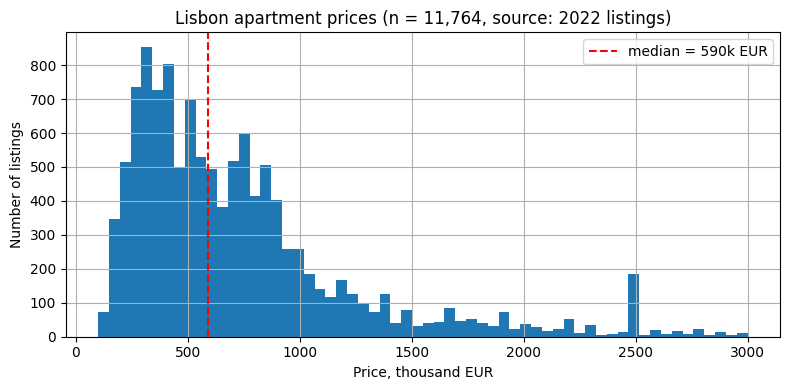

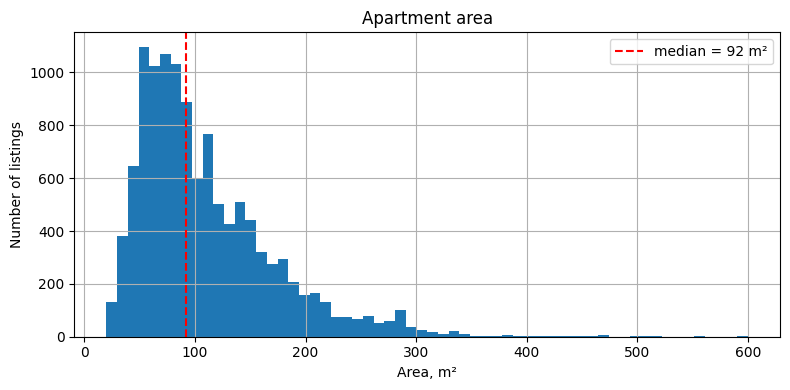

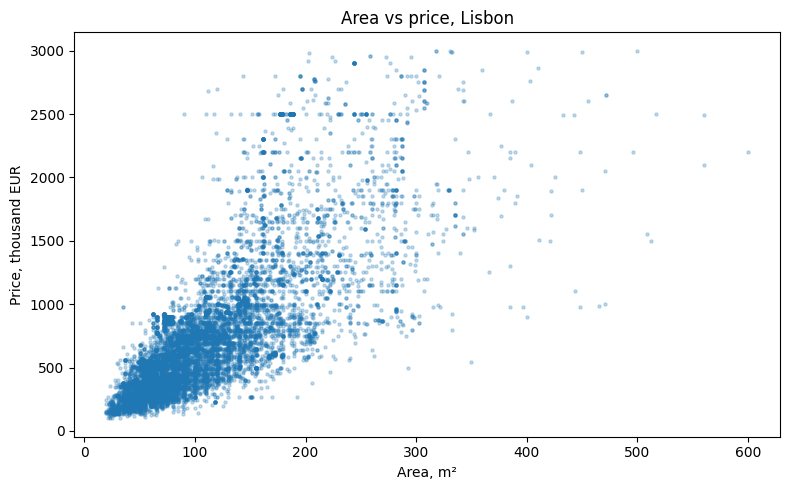

In [29]:
# cell 11 — plots (improved)

# 1. Price distribution
plt.figure(figsize=(8, 4))
(df['price_int'] / 1000).hist(bins=60)
plt.title('Lisbon apartment prices (n = 11,764, source: 2022 listings)')
plt.xlabel('Price, thousand EUR')
plt.ylabel('Number of listings')
plt.axvline(df['price_int'].median() / 1000, color='red', linestyle='--',
            label=f"median = {df['price_int'].median()/1000:.0f}k EUR")
plt.legend()
plt.tight_layout()
plt.show()

# 2. Area distribution
plt.figure(figsize=(8, 4))
df['area'].hist(bins=60)
plt.title('Apartment area')
plt.xlabel('Area, m²')
plt.ylabel('Number of listings')
plt.axvline(df['area'].median(), color='red', linestyle='--',
            label=f"median = {df['area'].median():.0f} m²")
plt.legend()
plt.tight_layout()
plt.show()

# 3. Area vs price
plt.figure(figsize=(8, 5))
plt.scatter(df['area'], df['price_int'] / 1000, s=5, alpha=0.25)
plt.title('Area vs price, Lisbon')
plt.xlabel('Area, m²')
plt.ylabel('Price, thousand EUR')
plt.tight_layout()
plt.show()

In [30]:
# cell 12
df.to_csv("data/lisbon_clean.csv", index=False)
print("Saved rows:", len(df))

Saved rows: 11764


**Threshold rationale:** median apartment is ~95 m² / ~€580k; extreme values
(1 m², 1.28M m², €600, €15M) are land plots, parking spaces or data errors.
Cut to 20–600 m² and €50k–3M. Typologies above T5 (up to "T40") are whole
buildings / investment lots, not apartments — kept T0–T5 to match the target user.


**Threshold rationale:** median apartment is ~95 m² / ~€580k; extreme values
(1 m², 1.28M m², €600, €15M) are land plots, parking spaces or data errors.
Cut to 20–600 m² and €50k–3M. Typologies above T5 (up to "T40") are whole
buildings / investment lots, not apartments — kept T0–T5 to match the target user.